# 구글 드라이브 마운트

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 데이터 경로 생성

In [2]:
import os

# Create the directories if they don't exist
os.makedirs('/content/llm_dataset/test', exist_ok=True)
os.makedirs('/content/llm_dataset/train', exist_ok=True)

print("Directories '/content/llm_dataset/test' and '/content/llm_dataset/train' created.")

Directories '/content/llm_dataset/test' and '/content/llm_dataset/train' created.


# 데이터 압축 해제

In [29]:
!unzip -q /content/drive/MyDrive/test_조립모듈/VL_중간조립모듈_zipped.zip -d /content/llm_dataset/test
!unzip -q /content/drive/MyDrive/test_조립모듈/VS_중간조립모듈_zipped.zip -d /content/llm_dataset/test
!unzip -q /content/drive/MyDrive/train_조립모듈/TL_중간조립모듈_zipped.zip -d /content/llm_dataset/train
!unzip -q /content/drive/MyDrive/train_조립모듈/TS_중간조립모듈_zipped.zip -d /content/llm_dataset/train

replace /content/llm_dataset/test/Module_001_A_CV_00_0100.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: warning:  stripped absolute path spec from /Module_001_A_CV_00_0013.jpg
replace /content/llm_dataset/test/Module_001_A_CV_00_0013.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: warning:  stripped absolute path spec from /Module_001_A_CV_00_0020.json
replace /content/llm_dataset/train/Module_001_A_CV_00_0020.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: warning:  stripped absolute path spec from /Module_001_A_CV_00_0008.jpg
replace /content/llm_dataset/train/Module_001_A_CV_00_0008.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [4]:
import glob

# JSON 파일 개수 카운트
train_files = glob.glob('/content/llm_dataset/train/**/*.json', recursive=True)
test_files = glob.glob('/content/llm_dataset/test/**/*.json', recursive=True)

train_count = len(train_files)
test_count = len(test_files)
total_count = train_count + test_count

print("=== 데이터셋 분할 및 개수 확인 ===")
print(f"학습(Train) 데이터: {train_count:,}개")
print(f"검증/평가(Test) 데이터: {test_count:,}개")
print(f"전체 데이터: {total_count:,}개")

if total_count > 0:
    train_ratio = (train_count / total_count) * 100
    test_ratio = (test_count / total_count) * 100
    print(f"\n분할 비율: 학습 {train_ratio:.1f}% : 검증 {test_ratio:.1f}%")

=== 데이터셋 분할 및 개수 확인 ===
학습(Train) 데이터: 174,267개
검증/평가(Test) 데이터: 21,799개
전체 데이터: 196,066개

분할 비율: 학습 88.9% : 검증 11.1%


# 필요 라이브러리 설치

In [5]:
!pip install ultralytics
!pip install grad-cam
!pip install chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 9.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.7-py3-none-any.whl size=53345 sha256=b4da5f70c19281fa6672c6fb875b9ad212def327a62a950e00338a8df62b99fa
  Stored in directory: /root/.cache/pip/wheels/91/36/f0/c2367865493d51b13369769181beca14603d17d6539a5922e3
Successfully built grad-cam
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━

# YOLO-ResNet 통합 파이프라인


In [7]:
import torch
import torch.nn as nn
from torchvision.models import resnet18
import torchvision.transforms as transforms
from ultralytics import YOLO

# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ResNet 모델 정의
class AssemblyResNet(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        # 사전 학습된 ResNet18 로드
        self.model = resnet18(weights=None)

        # 미세 단차(1~2mm 나사선 등) 학습을 위해 모든 파라미터 동결 해제 (Fine-tuning)
        for param in self.model.parameters():
            param.requires_grad = True

        # 4-Class(완전체결, 부분체결, 미체결, 오류체결) 분류를 위해 마지막 FC 레이어 수정
        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

# 1. ResNet 모델 로드
RESNET_WEIGHTS_PATH = '/content/drive/MyDrive/YOLO_ResNet/trained_weights/best_classification_resnet_finetuned.pth'
classification_model = AssemblyResNet(num_classes=4).to(device)
classification_model.load_state_dict(torch.load(RESNET_WEIGHTS_PATH, map_location=device))
classification_model.eval()

# 2. YOLO 모델 로드
YOLO_WEIGHTS_PATH = '/content/drive/MyDrive/YOLO_ResNet/trained_weights/yolo_train_results_v12/part_type_detection_v12/weights/best.pt'
eval_model = YOLO(YOLO_WEIGHTS_PATH)

# 3. Transform 및 클래스 정의
transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

resnet_classes = ['정상', '부분체결', '미체결', '오류체결']
print("모델 로드 완료! 이제 아래의 평가 셀을 실행하실 수 있습니다.")

모델 로드 완료! 이제 아래의 평가 셀을 실행하실 수 있습니다.


# YOLO-ResNet 통합 성능 테스트

In [ ]:
import os
import glob
import json
import numpy as np
import cv2
import torch
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import classification_report

# ==========================================
# 1. 평가용 데이터 준비
# ==========================================
# 전체 테스트 데이터 탐색
test_jsons = sorted(glob.glob('/content/llm_dataset/test/**/*.json', recursive=True))
print(f"평가용 JSON 파일 수: {len(test_jsons)}")

# 체크포인트 파일명도 분리하여 꼬이지 않게 방지
CHECKPOINT_FILE = '/content/evaluation_checkpoint_test.json'

if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, 'r', encoding='utf-8') as f:
        checkpoint = json.load(f)
    processed_files = set(checkpoint.get('processed_files', []))
    yolo_gt = checkpoint.get('yolo_gt', [])
    yolo_pred = checkpoint.get('yolo_pred', [])
    resnet_gt = checkpoint.get('resnet_gt', [])
    resnet_pred = checkpoint.get('resnet_pred', [])

    # 기존 체크포인트에 잘못 저장된 정답 라벨들 일괄 수정 (재평가 방지)
    fix_map = {'완전체결 상태': '정상', '부분체결 상태': '부분체결', '미체결 상태': '미체결', '오류체결 상태': '오류체결'}
    resnet_gt = [fix_map.get(x, x) for x in resnet_gt]

    print(f"🔄 체크포인트 로드 완료: 이미 처리된 {len(processed_files)}개를 제외하고 이어서 진행합니다.")
else:
    processed_files = set()
    yolo_gt, yolo_pred = [], []
    resnet_gt, resnet_pred = [], []

# 아직 처리되지 않은 파일만 필터링
sample_jsons = [f for f in test_jsons if f not in processed_files]
print(f"▶ 남은 평가 대상: {len(sample_jsons)}개")

# 데이터셋에 실제로 들어있는 한글 상태값들까지 모두 매핑되도록 추가
status_mapping = {
    '0_Normal': '정상',
    '1_Partial': '부분체결',
    '2_Missing': '미체결',
    '3_Error': '오류체결',
    '완전체결 상태': '정상',
    '부분체결 상태': '부분체결',
    '미체결 상태': '미체결',
    '오류체결 상태': '오류체결'
}

# ==========================================
# 2. 모델 추론 진행
# ==========================================
for i, json_path in enumerate(tqdm(sample_jsons)):
    img_path = json_path.rsplit('.', 1)[0] + '.jpg'
    if not os.path.exists(img_path):
        processed_files.add(json_path)
        continue

    # JSON 기반 Ground Truth 로드
    with open(json_path, 'r', encoding='utf-8-sig') as f:
        data = json.load(f)

    gt_parts = []
    gt_statuses = []
    for ann in data.get('Annotation', []):
        part = ann.get('Annotation_part_type')
        status = ann.get('Subclass_status')
        if part and status:
            gt_parts.append(part)
            gt_statuses.append(status_mapping.get(status, status))

    if not gt_parts:
        processed_files.add(json_path)
        continue

    orig_img_bgr = cv2.imread(img_path)
    if orig_img_bgr is None:
        processed_files.add(json_path)
        continue

    orig_img_rgb = cv2.cvtColor(orig_img_bgr, cv2.COLOR_BGR2RGB)

    # YOLO 추론 최적화 (해상도 640 고정, 최대 탐지 개수 제한)
    results = eval_model.predict(img_path, conf=0.5, imgsz=640, max_det=10, agnostic_nms=False, verbose=False)[0]
    boxes_data = results.boxes.data.cpu().numpy()

    pred_parts = []
    pred_statuses = []

    for row in boxes_data:
        x1, y1, x2, y2, conf, cls = row
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        pred_parts.append(results.names[int(cls)])

        # ResNet 추론을 위한 Crop 및 Transform
        bw, bh = x2 - x1, y2 - y1
        mx, my = int(bw * 0.2), int(bh * 0.2)
        cx1, cy1 = max(0, x1 - mx), max(0, y1 - my)
        cx2, cy2 = min(orig_img_rgb.shape[1], x2 + mx), min(orig_img_rgb.shape[0], y2 + my)

        crop_pil = Image.fromarray(orig_img_rgb[cy1:cy2, cx1:cx2])
        w, h = crop_pil.size
        max_wh = max(w, h)
        padded = Image.new('RGB', (max_wh, max_wh), (0, 0, 0))
        padded.paste(crop_pil, ((max_wh - w) // 2, (max_wh - h) // 2))
        input_tensor = transform_val(padded.resize((224, 224))).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = classification_model(input_tensor)
            pred_idx = outputs.argmax(dim=1).item()
            pred_statuses.append(resnet_classes[pred_idx])

    # 매칭 및 지표 누적
    gt_parts.sort()
    pred_parts.sort()

    min_len_yolo = min(len(gt_parts), len(pred_parts))
    yolo_gt.extend(gt_parts[:min_len_yolo])
    yolo_pred.extend(pred_parts[:min_len_yolo])

    for gt in gt_parts[min_len_yolo:]:
        yolo_gt.append(gt)
        yolo_pred.append('None(Missed)')
    for p in pred_parts[min_len_yolo:]:
        yolo_gt.append('None(False_Alarm)')
        yolo_pred.append(p)

    gt_statuses.sort()
    pred_statuses.sort()

    min_len_resnet = min(len(gt_statuses), len(pred_statuses))
    resnet_gt.extend(gt_statuses[:min_len_resnet])
    resnet_pred.extend(pred_statuses[:min_len_resnet])

    for gt in gt_statuses[min_len_resnet:]:
        resnet_gt.append(gt)
        resnet_pred.append('None(Missed)')
    for p in pred_statuses[min_len_resnet:]:
        resnet_gt.append('None(False_Alarm)')
        resnet_pred.append(p)

    # 처리 완료 파일 기록
    processed_files.add(json_path)

    # 500개 처리할 때마다 진행상황 저장 (체크포인트)
    if (i + 1) % 500 == 0 or (i + 1) == len(sample_jsons):
        with open(CHECKPOINT_FILE, 'w', encoding='utf-8') as f:
            json.dump({
                'processed_files': list(processed_files),
                'yolo_gt': yolo_gt,
                'yolo_pred': yolo_pred,
                'resnet_gt': resnet_gt,
                'resnet_pred': resnet_pred
            }, f)

# ==========================================
# 3. 성능 결과 출력
# ==========================================
if len(yolo_gt) > 0:
    print("\n==========================================")
    print(f" 📊 Clean Test YOLO 부품 검출(Part Type) 성능 (총 {len(processed_files)}개 기준)")
    print("==========================================")
    print(classification_report(yolo_gt, yolo_pred, zero_division=0))

    print("\n==========================================")
    print(f" 📊 Clean Test ResNet 체결 상태(Status) 성능 (총 {len(processed_files)}개 기준)")
    print("==========================================")
    print(classification_report(resnet_gt, resnet_pred, zero_division=0))
else:
    print("평가 결과가 없습니다.")

평가용 JSON 파일 수: 21799
▶ 남은 평가 대상: 21799개


  0%|          | 0/21799 [00:00<?, ?it/s]


 📊 Clean Test YOLO 부품 검출(Part Type) 성능 (총 21799개 기준)
                   precision    recall  f1-score   support

             GPC형       0.97      0.90      0.94      4871
           GPL45형       0.91      0.80      0.85      2136
             GPL형       0.88      0.80      0.84      2903
            KCPC형       0.98      0.96      0.97     22653
           KCPLV형       1.00      0.98      0.99        88
           KRPPL형       0.95      0.94      0.95     13286
            KRPT형       0.90      0.93      0.92       142
           KRPUC형       0.94      0.93      0.93     14063
           KRPUL형       0.95      0.95      0.95        96
            KRPY형       0.94      0.94      0.94      4601
           KRPZA형       0.86      0.81      0.84        79
           KSPHL형       0.95      0.96      0.96        83
          KSPL45형       0.94      0.94      0.94      3113
           KSPPL형       0.84      0.87      0.85        30
None(False_Alarm)       0.00      0.00      0.00      1368
 

# 전처리 방식에 따른 ResNet 성능 비교 (비교군 검증)
제안하는 **YOLO-ResNet 파이프라인(마진 20% + SquarePad)**의 효과를 검증하기 위해 4가지 방식을 비교합니다.
1. **Baseline**: YOLO 없이 원본 이미지 전체를 ResNet에 입력
2. **비교군 1 (Margin 0%)**: YOLO 바운딩 박스 영역만 딱 맞게 Crop 하여 입력
3. **비교군 2 (Margin 20% + Resize)**: 20% 마진을 주고 Crop 한 뒤, 종횡비를 무시하고 224x224로 강제 Resize
4. **제안 모델 (Margin 20% + SquarePad)**: 20% 마진 Crop 후 종횡비를 유지하며 빈 공간을 패딩 처리 후 224x224로 변환

Ablation Study 진행 중... 통합 테스트 방식 적용 (Missed/False Alarm 포함) (샘플 21799개)


  0%|          | 0/21799 [00:00<?, ?it/s]


=== Ablation Study 결과 (Accuracy - 통합 테스트 기준) ===
- Baseline: 0.2865
- Crop_0: 0.6459
- Crop_20_Resize: 0.8415
- Crop_20_Pad: 0.9225


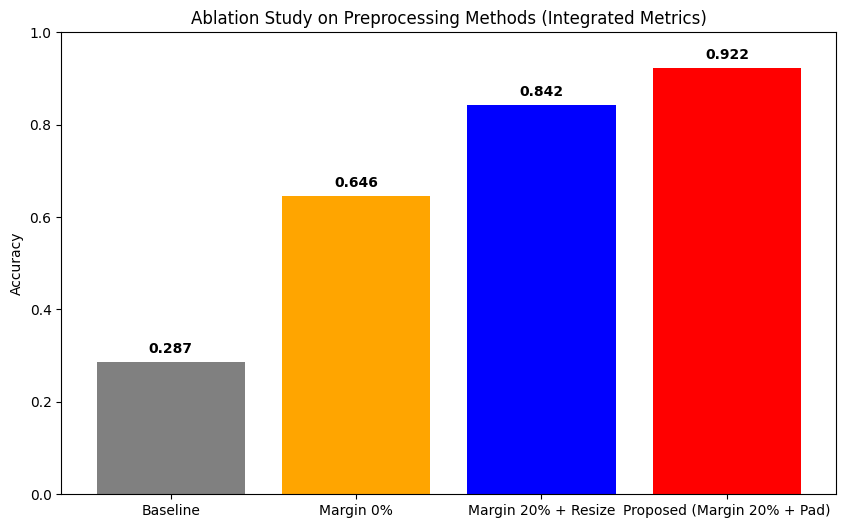

In [ ]:
import os
import glob
import json
import cv2
import torch
from PIL import Image
import torchvision.transforms as transforms
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 검증용 파일 목록 가져오기 (전체 테스트 데이터 사용)
all_test_jsons = sorted(glob.glob('/content/llm_dataset/test/**/*.json', recursive=True))
sample_jsons_ablation = all_test_jsons

# 라벨 상태 매핑 딕셔너리
status_mapping = {
    '0_Normal': '정상',
    '1_Partial': '부분체결',
    '2_Missing': '미체결',
    '3_Error': '오류체결',
    '완전체결 상태': '정상',
    '부분체결 상태': '부분체결',
    '미체결 상태': '미체결',
    '오류체결 상태': '오류체결'
}

# Transform 정의
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def square_pad(pil_img):
    w, h = pil_img.size
    max_wh = max(w, h)
    padded = Image.new('RGB', (max_wh, max_wh), (0, 0, 0))
    padded.paste(pil_img, ((max_wh - w) // 2, (max_wh - h) // 2))
    return padded

# 결과 저장용
results = {
    'Baseline': {'gt': [], 'pred': []},
    'Crop_0': {'gt': [], 'pred': []},
    'Crop_20_Resize': {'gt': [], 'pred': []},
    'Crop_20_Pad': {'gt': [], 'pred': []}
}

print(f"Ablation Study 진행 중... 통합 테스트 방식 적용 (Missed/False Alarm 포함) (샘플 {len(sample_jsons_ablation)}개)")
for json_path in tqdm(sample_jsons_ablation):
    img_path = json_path.rsplit('.', 1)[0] + '.jpg'
    if not os.path.exists(img_path): continue

    # GT 로드
    with open(json_path, 'r', encoding='utf-8-sig') as f:
        data = json.load(f)

    gt_statuses = []
    for ann in data.get('Annotation', []):
        st = ann.get('Subclass_status')
        if st:
            gt_statuses.append(status_mapping.get(st, st))

    if not gt_statuses: continue

    orig_img_bgr = cv2.imread(img_path)
    if orig_img_bgr is None: continue
    orig_img_rgb = cv2.cvtColor(orig_img_bgr, cv2.COLOR_BGR2RGB)
    orig_pil = Image.fromarray(orig_img_rgb)

    # YOLO 추론 (객체 위치 파악)
    yolo_res = eval_model.predict(img_path, conf=0.5, imgsz=640, max_det=10, verbose=False)[0]
    boxes_data = yolo_res.boxes.data.cpu().numpy()

    # 1. Baseline: 원본 전체 추론 (이미지당 1번만 수행하여 효율성 확보)
    t_base = base_transform(orig_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        base_pred = resnet_classes[classification_model(t_base).argmax().item()]

    # 각 방식별 예측 결과 임시 저장
    preds_base = []
    preds_crop0 = []
    preds_crop20_res = []
    preds_crop20_pad = []

    # 탐지된 객체에 대해 검사 진행
    for row in boxes_data:
        x1, y1, x2, y2, conf, cls = row
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

        # 2. Crop 0%
        crop_0 = Image.fromarray(orig_img_rgb[y1:y2, x1:x2])
        t_crop_0 = base_transform(crop_0).unsqueeze(0).to(device) if crop_0.size[0]>0 and crop_0.size[1]>0 else t_base

        # 3. Crop 20% + 일반 Resize
        bw, bh = x2 - x1, y2 - y1
        mx, my = int(bw * 0.2), int(bh * 0.2)
        cx1, cy1 = max(0, x1 - mx), max(0, y1 - my)
        cx2, cy2 = min(orig_img_rgb.shape[1], x2 + mx), min(orig_img_rgb.shape[0], y2 + my)
        crop_20 = Image.fromarray(orig_img_rgb[cy1:cy2, cx1:cx2])
        t_crop_20_resize = base_transform(crop_20).unsqueeze(0).to(device) if crop_20.size[0]>0 and crop_20.size[1]>0 else t_base

        # 4. Crop 20% + SquarePad (제안 방식)
        t_crop_20_pad = base_transform(square_pad(crop_20)).unsqueeze(0).to(device) if crop_20.size[0]>0 and crop_20.size[1]>0 else t_base

        with torch.no_grad():
            preds_base.append(base_pred)
            preds_crop0.append(resnet_classes[classification_model(t_crop_0).argmax().item()])
            preds_crop20_res.append(resnet_classes[classification_model(t_crop_20_resize).argmax().item()])
            preds_crop20_pad.append(resnet_classes[classification_model(t_crop_20_pad).argmax().item()])

    # === 통합 성능 테스트와 완벽히 동일한 매칭/패널티 로직 ===
    gt_statuses.sort()
    preds_base.sort()
    preds_crop0.sort()
    preds_crop20_res.sort()
    preds_crop20_pad.sort()

    min_len = min(len(gt_statuses), len(boxes_data))

    def add_results(method_name, preds_list):
        results[method_name]['gt'].extend(gt_statuses[:min_len])
        results[method_name]['pred'].extend(preds_list[:min_len])

        # YOLO가 놓친 것(Missed) 패널티
        for gt in gt_statuses[min_len:]:
            results[method_name]['gt'].append(gt)
            results[method_name]['pred'].append('None(Missed)')

        # YOLO가 잘못 찾은 것(False Alarm) 패널티
        for p in preds_list[min_len:]:
            results[method_name]['gt'].append('None(False_Alarm)')
            results[method_name]['pred'].append(p)

    add_results('Baseline', preds_base)
    add_results('Crop_0', preds_crop0)
    add_results('Crop_20_Resize', preds_crop20_res)
    add_results('Crop_20_Pad', preds_crop20_pad)

# 결과 출력
print("\n=== Ablation Study 결과 (Accuracy - 통합 테스트 기준) ===")
for k in results:
    acc = accuracy_score(results[k]['gt'], results[k]['pred']) if len(results[k]['gt']) > 0 else 0
    print(f"- {k}: {acc:.4f}")

# 바 그래프 시각화
acc_scores = [accuracy_score(results[k]['gt'], results[k]['pred']) if len(results[k]['gt']) > 0 else 0 for k in results]
plt.figure(figsize=(10, 6))
plt.bar(['Baseline', 'Margin 0%', 'Margin 20% + Resize', 'Proposed (Margin 20% + Pad)'], acc_scores, color=['gray', 'orange', 'blue', 'red'])
plt.title('Ablation Study on Preprocessing Methods (Integrated Metrics)')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)
for i, v in enumerate(acc_scores):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()


# 시각화 및 출력 결과 확인

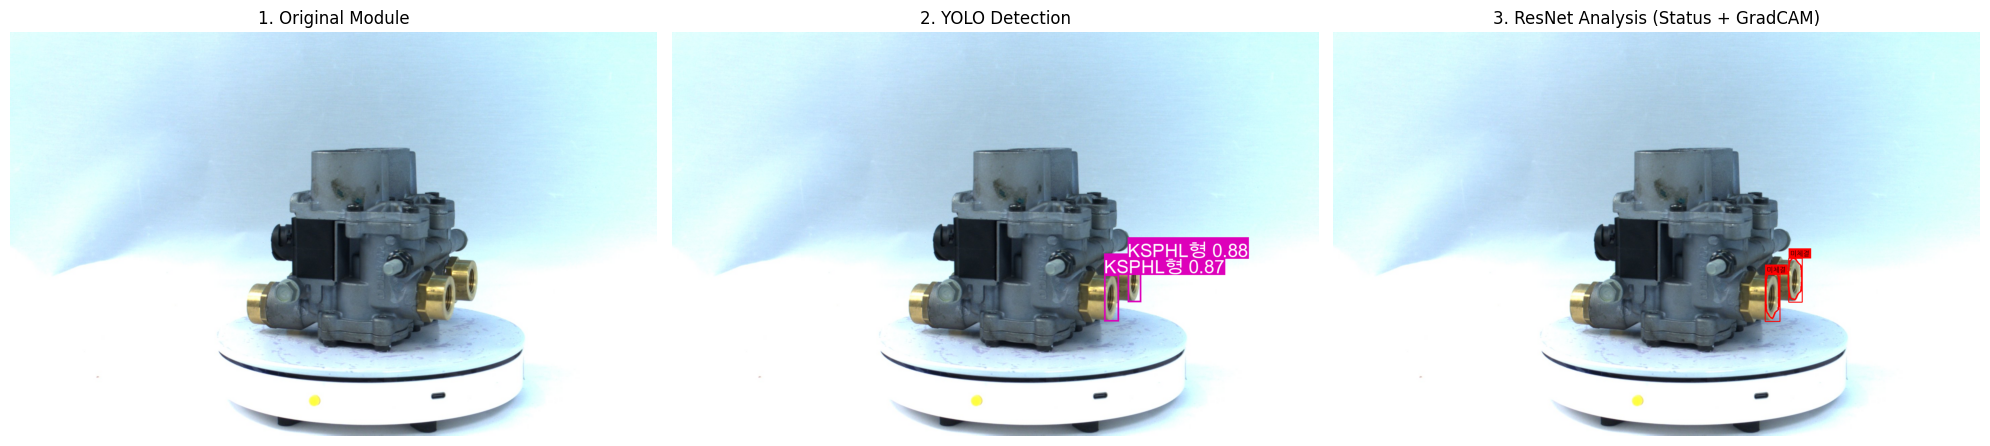

--- 검출 및 진단 결과 ---
[
  {
    "part_name": "KSPHL형",
    "status": "미체결",
    "yolo_confidence": 0.880075991153717,
    "resnet_confidence": 1.0
  },
  {
    "part_name": "KSPHL형",
    "status": "미체결",
    "yolo_confidence": 0.8731943368911743,
    "resnet_confidence": 1.0
  }
]




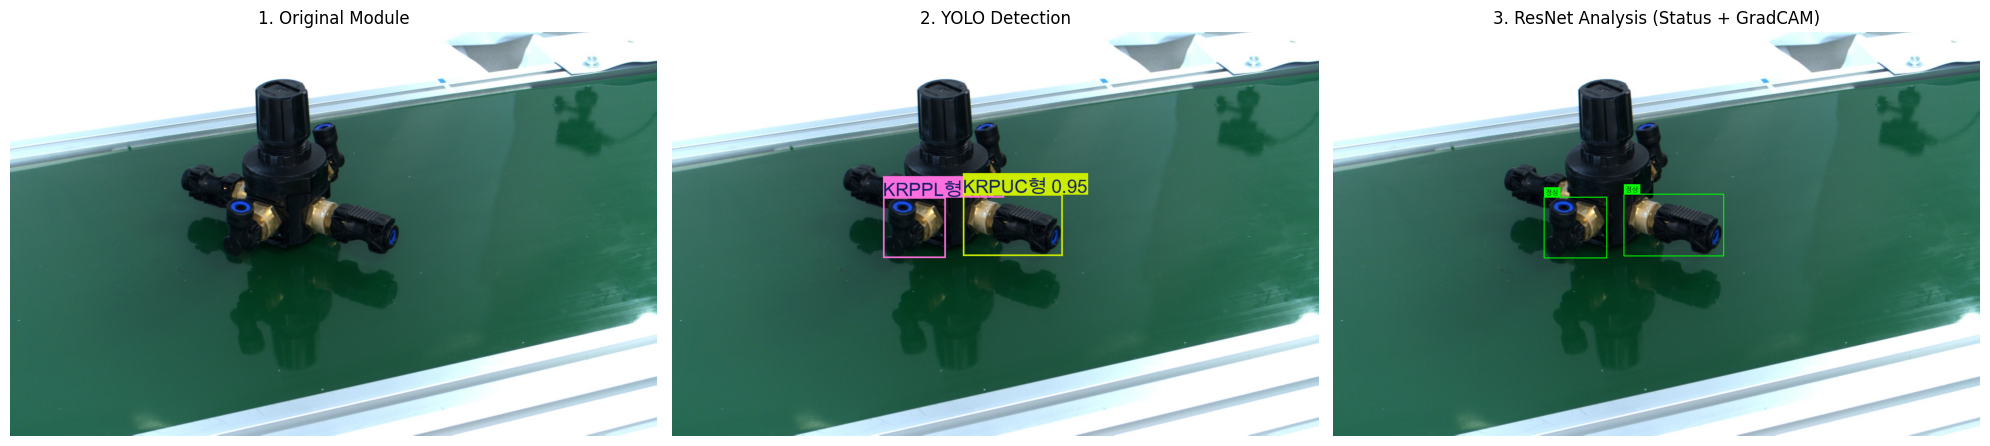

--- 검출 및 진단 결과 ---
[
  {
    "part_name": "KRPUC형",
    "status": "정상",
    "yolo_confidence": 0.9498953223228455,
    "resnet_confidence": 1.0
  },
  {
    "part_name": "KRPPL형",
    "status": "정상",
    "yolo_confidence": 0.9247206449508667,
    "resnet_confidence": 0.9999977350234985
  }
]




In [17]:
import os
import glob
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import urllib.request
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import json

# ==========================================
# 0. 한글 폰트 다운로드 (cv2 한글 깨짐 방지)
# ==========================================
font_path = 'NanumGothic.ttf'

if not os.path.exists(font_path):
    urllib.request.urlretrieve("https://hangeul.pstatic.net/hangeul_static/webfont/NanumGothic/NanumGothic.ttf", font_path)

# ==========================================
# 1. 환경 설정 및 기존 로드된 모델 재사용
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# (이전 셀 cb1efc3f 에서 classification_model 과 eval_model이 이미 로드되어 있어야 합니다.)

# ==========================================
# 2. Grad-CAM 타겟 레이어 및 Transform 설정
# ==========================================
# AssemblyResNet 내부에 있는 resnet18(self.model)의 layer4 마지막 블록을 타겟으로 설정
target_layers = [classification_model.model.layer4[-1]]

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

resnet_classes = ['정상', '부분체결', '미체결', '오류체결']

# ==========================================
# 3. 통합 파이프라인 함수 정의 (Standard ResNet)
# ==========================================
def run_integrated_pipeline(img_path, yolo_model, resnet_model, cam_target_layers):
    orig_img_bgr = cv2.imread(img_path)
    if orig_img_bgr is None:
        print(f"이미지를 읽을 수 없습니다: {img_path}")
        return None, None

    orig_img_rgb = cv2.cvtColor(orig_img_bgr, cv2.COLOR_BGR2RGB)

    # YOLO 탐지
    yolo_results = yolo_model.predict(img_path, conf=0.5, agnostic_nms=False, verbose=False)[0]

    # 레퍼런스 이미지가 없으므로 3개의 subplot으로 구성
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    axes[0].imshow(orig_img_rgb)
    axes[0].set_title("1. Original Module")
    axes[0].axis('off')

    img_yolo = yolo_results.plot()
    img_yolo_rgb = cv2.cvtColor(img_yolo, cv2.COLOR_BGR2RGB)
    axes[1].imshow(img_yolo_rgb)
    axes[1].set_title("2. YOLO Detection")
    axes[1].axis('off')

    analysis_viz = orig_img_rgb.copy()
    boxes_data = yolo_results.boxes.data.cpu().numpy()

    report_results = []

    # GradCAM 객체 생성
    cam_obj = GradCAM(model=resnet_model, target_layers=cam_target_layers)

    for row in boxes_data:
        x1, y1, x2, y2, conf, cls = row
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        yolo_class_name = yolo_results.names[int(cls)]

        bw, bh = x2 - x1, y2 - y1
        mx, my = int(bw * 0.2), int(bh * 0.2)

        cx1, cy1 = max(0, x1 - mx), max(0, y1 - my)
        cx2, cy2 = min(orig_img_rgb.shape[1], x2 + mx), min(orig_img_rgb.shape[0], y2 + my)

        crop_pil = Image.fromarray(orig_img_rgb[cy1:cy2, cx1:cx2])

        w, h = crop_pil.size
        max_wh = max(w, h)
        padded = Image.new('RGB', (max_wh, max_wh), (0, 0, 0))
        padded.paste(crop_pil, ((max_wh - w) // 2, (max_wh - h) // 2))
        input_tensor = transform_val(padded.resize((224, 224))).unsqueeze(0).to(device)

        # Standard ResNet Inference
        with torch.no_grad():
            outputs = resnet_model(input_tensor)
            probabilities = F.softmax(outputs, dim=1)
            best_conf, best_pred_idx_tensor = probabilities.max(dim=1)
            best_conf = best_conf.item()
            best_pred_idx = best_pred_idx_tensor.item()

        label_text = resnet_classes[best_pred_idx]

        report_results.append({
            "part_name": yolo_class_name,
            "status": label_text,
            "yolo_confidence": float(conf),
            "resnet_confidence": float(best_conf)
        })

        if best_pred_idx != 0:
            # 정상(0)이 아닐 때만 Grad-CAM 적용
            targets = [ClassifierOutputTarget(best_pred_idx)]
            grayscale_cam = cam_obj(input_tensor=input_tensor, targets=targets)[0, :]
            mask = (grayscale_cam > 0.5).astype(np.uint8) * 255
            mask_resized = cv2.resize(mask, (cx2 - cx1, cy2 - cy1))

            crop_np = orig_img_rgb[cy1:cy2, cx1:cx2]
            padding_filter = np.all(crop_np < 10, axis=-1)
            mask_resized[padding_filter] = 0

            contours, _ = cv2.findContours(mask_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(analysis_viz[cy1:cy2, cx1:cx2], contours, -1, (255, 0, 0), 3)

        color_map = {0: (0, 255, 0), 1: (255, 165, 0), 2: (255, 0, 0), 3: (255, 0, 255)}
        class_color = color_map.get(best_pred_idx, (255, 0, 0))

        cv2.rectangle(analysis_viz, (x1, y1), (x2, y2), class_color, 2)

        pil_img_for_text = Image.fromarray(analysis_viz)
        draw = ImageDraw.Draw(pil_img_for_text)
        korean_font = ImageFont.truetype(font_path, 20)

        bbox = draw.textbbox((0, 0), label_text, font=korean_font)
        text_w = bbox[2] - bbox[0]
        text_h = bbox[3] - bbox[1]

        draw.rectangle([(x1, y1 - text_h - 10), (x1 + text_w + 10, y1)], fill=class_color)
        draw.text((x1 + 5, y1 - text_h - 7), label_text, font=korean_font, fill=(0, 0, 0))

        analysis_viz = np.array(pil_img_for_text)

    axes[2].imshow(analysis_viz)
    axes[2].set_title("3. ResNet Analysis (Status + GradCAM)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    return report_results, analysis_viz

# ==========================================
# 4. 테스트 실행
# ==========================================
test_images = glob.glob('/content/llm_dataset/test/**/*.jpg', recursive=True)
if test_images:
    num_samples = min(2, len(test_images))
    sampled_test = random.sample(test_images, num_samples)
    for path in sampled_test:
        results, final_img = run_integrated_pipeline(path, eval_model, classification_model, target_layers)
        print("--- 검출 및 진단 결과 ---")
        print(json.dumps(results, indent=2, ensure_ascii=False))
        print("\n")


# 학습 JSON 파일로 RAG 지식 DB 구축하기
`train` 폴더의 JSON 라벨 데이터를 읽어와 SQLite DB(`maintenance.db`)를 생성합니다.

In [8]:
import os
import glob
import json
import sqlite3

# 새롭게 생성할 로컬 DB 경로
DB_PATH = '/content/maintenance.db'

def build_maintenance_db(json_folder='/content/llm_dataset/train'):
    json_files = glob.glob(f"{json_folder}/**/*.json", recursive=True)

    if not json_files:
        print(f"'{json_folder}' 경로에 JSON 파일이 없습니다. 훈련 데이터를 먼저 압축 해제해주세요!")
        return

    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    # 지식 DB 테이블 생성
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS maintenance_kb (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            part_type TEXT,
            subclass_status TEXT,
            action TEXT
        )
    ''')

    # 기존 데이터 초기화 (재실행 시 중복 방지)
    cursor.execute('DELETE FROM maintenance_kb')

    count = 0
    for jp in json_files:
        try:
            with open(jp, 'r', encoding='utf-8-sig') as f:
                data = json.load(f)

            # Annotation 내부의 부품, 상태, 조치(Action) 정보 추출
            for ann in data.get('Annotation', []):
                part_type = ann.get('Annotation_part_type')
                status = ann.get('Subclass_status')
                action = ann.get('Action')

                # 결측치 방지 및 조치 데이터가 존재하는 경우만 삽입
                if part_type and status and action and str(action).strip() != "None":
                    cursor.execute('''
                        INSERT INTO maintenance_kb (part_type, subclass_status, action)
                        VALUES (?, ?, ?)
                    ''', (part_type, status, action))
                    count += 1
        except Exception as e:
            print(f"파일 읽기 오류 ({jp}): {e}")

    conn.commit()
    conn.close()
    print(f"RAG DB 구축 완료! 총 {count}건의 조치 이력이 '{DB_PATH}'에 저장되었습니다.")

# DB 구축 실행
build_maintenance_db('/content/llm_dataset/train')

# 기존에 선언된 query_maintenance_db 함수가 새로운 로컬 DB_PATH를 참조하도록 덮어쓰기
def query_maintenance_db(part_name, status):
    if not os.path.exists(DB_PATH):
        return "DB 파일을 찾을 수 없습니다."
    try:
        conn = sqlite3.connect(DB_PATH)
        # '2_Missing' 등에서 텍스트 부분만 추출하여 유연하게 검색
        status_clean = status.split('_')[-1] if '_' in status else status

        query = """
            SELECT action FROM maintenance_kb
            WHERE part_type=? AND subclass_status LIKE ?
            LIMIT 5
        """
        rows = conn.execute(query, (part_name, f"%{status_clean}%")).fetchall()
        conn.close()

        if rows:
            # 중복 조치 내용 제거 후 반환
            unique_actions = list(set([r[0] for r in rows]))
            return unique_actions
        return "과거 조치 이력이 없습니다."
    except Exception as e:
        return f"DB 조회 오류: {e}"


RAG DB 구축 완료! 총 543101건의 조치 이력이 '/content/maintenance.db'에 저장되었습니다.


# Vector DB (ChromaDB) 초기화 및 데이터 임베딩
기존 SQLite에 저장된 조치 이력을 Sentence-Transformers를 이용해 벡터화하여 ChromaDB에 적재합니다.

In [9]:
import sqlite3
import chromadb
from chromadb.utils import embedding_functions
from tqdm.auto import tqdm

print("ChromaDB 초기화 및 SentenceTransformer 임베딩 로드 중...")
chroma_client = chromadb.PersistentClient(path="/content/chroma_db")

# 원본 노트북과 동일한 임베딩 모델 사용
emb_fn = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="jhgan/ko-sroberta-multitask"
)

collection = chroma_client.get_or_create_collection(
    name="assembly_maintenance_vectors",
    embedding_function=emb_fn,
    # ✨ 이 한 줄을 추가하여 코사인 유사도를 명시적으로 강제합니다!
    metadata={"hnsw:space": "cosine"}
)

# SQLite DB에서 데이터 불러오기
conn = sqlite3.connect('/content/maintenance.db')
rows = conn.execute("SELECT part_type, subclass_status, action FROM maintenance_kb").fetchall()
conn.close()

if collection.count() == 0 and rows:
    # 중복 제거를 통해 핵심 조치 방법들만 임베딩 (성능 최적화)
    unique_rows = list(set([(r[0], r[1], r[2]) for r in rows if str(r[2]).strip() != 'None']))

    print(f"총 {len(unique_rows)}개의 고유 조치 이력을 벡터 DB에 인덱싱합니다. (최초 1회 소요)")
    ids = []
    documents = []
    metadatas = []

    for i, (p_type, status, action) in enumerate(tqdm(unique_rows)):
        ids.append(str(i))
        # 검색 대상(Symptom)을 문서로 저장
        documents.append(f"{p_type} {status}")
        metadatas.append({
            "part_type": p_type,
            "subclass_status": status,
            "action": action
        })

    # 배치 사이즈 단위로 분할하여 업서트 (ChromaDB 제한 방지)
    batch_size = 5000
    for i in range(0, len(ids), batch_size):
        collection.upsert(
            ids=ids[i:i+batch_size],
            documents=documents[i:i+batch_size],
            metadatas=metadatas[i:i+batch_size]
        )
    print("✅ 벡터 DB 인덱싱 완료!")
else:
    print(f"✅ 벡터 DB가 이미 준비되어 있습니다. (현재 벡터 문서 수: {collection.count()})")

ChromaDB 초기화 및 SentenceTransformer 임베딩 로드 중...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.86k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

총 72개의 고유 조치 이력을 벡터 DB에 인덱싱합니다. (최초 1회 소요)


  0%|          | 0/72 [00:00<?, ?it/s]

✅ 벡터 DB 인덱싱 완료!


# Vector RAG 검색 및 통합 리포트 함수 정의
Vector DB 검색 함수 및 근본 원인 분석(Root Cause) 함수를 통합하여 파이프라인을 고도화합니다.

In [10]:
import sqlite3
import json
from PIL import Image

# ==========================================
# 단계 9-1: 사고 로그(Incident Log) DB 초기화
# ==========================================
def init_incident_log_db():
    conn = sqlite3.connect('/content/maintenance.db')
    conn.execute('''
        CREATE TABLE IF NOT EXISTS incident_log (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            timestamp DATETIME DEFAULT CURRENT_TIMESTAMP,
            part_name TEXT,
            status TEXT
        )
    ''')
    conn.commit()
    conn.close()

init_incident_log_db()

def log_incident(part_name, status):
    """단계 9-1: 사고 로그 축적 (INSERT)"""
    conn = sqlite3.connect('/content/maintenance.db')
    conn.execute("INSERT INTO incident_log (part_name, status) VALUES (?, ?)", (part_name, status))
    conn.commit()
    conn.close()

def check_repetition(part_name, status, threshold=2):
    """단계 9-2①: 통계적 반복 감지 (GROUP BY + HAVING)"""
    conn = sqlite3.connect('/content/maintenance.db')

    # 기획안에 맞춰 GROUP BY와 HAVING을 사용한 통계적 검사 쿼리
    query = """
        SELECT part_name, status, COUNT(*) as cnt
        FROM incident_log
        GROUP BY part_name, status
        HAVING cnt >= ? AND part_name = ? AND status = ?
    """
    row = conn.execute(query, (threshold, part_name, status)).fetchone()

    # 단순 누적 발생 횟수 표시를 위한 전체 카운트
    total_count = conn.execute("SELECT COUNT(*) FROM incident_log WHERE part_name=? AND status=?", (part_name, status)).fetchone()[0]
    conn.close()

    if row:
        return f"🚨 [반복 경고] 해당 불량은 누적 {total_count}회 발생하여 통계적 반복 기준치({threshold}회)를 초과했습니다! 고질적인 공정 문제일 수 있습니다."
    else:
        return f"누적 발생 횟수: {total_count}회 (기준치 미달, 우발적 불량으로 추정)"

# ==========================================
# Vector RAG 검색 로직
# ==========================================
def query_vector_db(part_name, status, top_k=3):
    """ChromaDB를 이용한 의미론적 벡터 유사도 검색"""
    query_text = f"{part_name} {status}"

    if 'collection' not in globals():
        return ["벡터 DB(ChromaDB)가 로드되지 않았습니다."]

    results = collection.query(
        query_texts=[query_text],
        n_results=top_k
    )

    actions = []
    if results['distances'] and results['distances'][0]:
        for meta in results['metadatas'][0]:
            actions.append(meta['action'])

    if actions:
        return list(set(actions))
    return ["유사한 과거 조치 이력을 찾지 못했습니다."]

print("✅ RAG 검색 및 사고 로그 함수 정의 완료 (이후 단계에서 Gemini LLM과 연동되어 통합 리포트를 생성합니다)")

✅ RAG 검색 및 사고 로그 함수 정의 완료 (이후 단계에서 Gemini LLM과 연동되어 통합 리포트를 생성합니다)


# Gemini 기반 리포트 생성 함수

In [24]:
import json
import google.generativeai as genai
from PIL import Image

def get_ai_root_cause_analysis(image_array, diagnosis_results):
    """Gemini를 활용하여 근본 원인 분석 및 조치 제안 텍스트만 순수하게 생성"""
    pil_img = Image.fromarray(image_array)

    rag_context = ""
    incident_stats_context = ""
    has_anomaly = False

    for item in diagnosis_results:
        if item['status'] != '정상':
            has_anomaly = True
            repetition_info = check_repetition(item['part_name'], item['status'])
            incident_stats_context += f"- {item['part_name']} {item['status']} ({repetition_info})\n"

            actions = query_vector_db(item['part_name'], item['status'])
            rag_context += f"- {item['part_name']}: {actions}\n"

    if not has_anomaly:
        return "현재 시스템 상 탐지된 불량이 없으며, 정상 가동 중입니다."

    prompt = f"""
    당신은 제조 공정의 스마트 팩토리 비전 검사 AI 어시스턴트입니다.
    제공된 [사고 로그 및 통계]와 [RAG 검색 조치 방안]을 바탕으로, 현재 발생한 불량의 근본 원인 분석과 구체적인 조치 제안을 3~4문장으로 간결하게 작성해주세요.
    마크다운 기호(#, *)를 최대한 배제하고 평문 형식으로 작성해주세요.

    [사고 로그 및 통계]
    {incident_stats_context.strip()}

    [RAG 검색 조치 방안]
    {rag_context.strip()}
    """

    try:
        response = gemini_model.generate_content([prompt, pil_img])
        return response.text
    except Exception as e:
        raise e

# HTML 기반 리포트 생성 함수

In [25]:
import base64
from io import BytesIO
import sqlite3
from IPython.display import display, HTML
import numpy as np
from PIL import Image

def image_to_base64(img_array):
    pil_img = Image.fromarray(img_array)
    buffered = BytesIO()
    pil_img.save(buffered, format="JPEG")
    return base64.b64encode(buffered.getvalue()).decode('utf-8')

def get_cumulative_fault_counts():
    conn = sqlite3.connect('/content/maintenance.db')
    query = "SELECT part_name, status, COUNT(*) as cnt FROM incident_log GROUP BY part_name, status ORDER BY cnt DESC"
    rows = conn.execute(query).fetchall()
    conn.close()
    return rows

def render_quality_report_with_ai(viz_img, diagnosis_results, ai_analysis_text, ragas_scores=None):
    if ragas_scores is None:
        ragas_scores = {"faithfulness": 0.900, "answer_relevancy": 0.739}

    yolo_confs = [item['yolo_confidence'] for item in diagnosis_results]
    resnet_confs = [item['resnet_confidence'] for item in diagnosis_results]
    yolo_avg = int(np.mean(yolo_confs) * 100) if yolo_confs else 0
    resnet_avg = int(np.mean(resnet_confs) * 100) if resnet_confs else 0

    anomalies = [item for item in diagnosis_results if item['status'] != '정상']
    status_label = anomalies[0]['status'] if anomalies else '정상'
    status_badge = f"❌ {status_label} (불량)" if anomalies else "✅ 정상 (양호)"
    badge_color = "#d9534f" if anomalies else "#5cb85c"

    fault_logs = get_cumulative_fault_counts()
    pattern_items = ""
    for part, st, cnt in fault_logs[:2]:
        pattern_items += f"<li><b>{part} {st} 누적 {cnt}회 발생</b></li>"
    if not pattern_items:
        pattern_items = "<li>누적 불량 이력이 존재하지 않습니다.</li>"

    img_b64 = image_to_base64(viz_img)

    # AI 텍스트의 줄바꿈을 HTML <br> 태그로 변환
    ai_text_html = ai_analysis_text.replace('\n', '<br>')

    html_content = f"""
    <div style="width: 820px; border: 2px solid #ccc; border-radius: 8px; font-family: 'NanumGothic', sans-serif; background: #fafafa; padding: 10px; margin: 15px auto;">
        <h2 style="text-align: left; margin: 5px 0 12px 10px; font-size: 19px; color: #111;">종합 품질 분석 및 진단 시스템 평가 보고서</h2>
        <div style="display: flex; gap: 10px;">
            <div style="flex: 1.1; display: flex; border: 1px solid #d0d0d0; border-radius: 6px; background: #fff; overflow: hidden;">
                <div style="flex: 1; border-right: 1px solid #e0e0e0; display: flex; flex-direction: column;">
                    <div style="background: #e6e6e6; padding: 6px; text-align: center; font-weight: bold; font-size: 13px; border-bottom: 1px solid #d0d0d0;">시각적 불량 탐지 결과</div>
                    <div style="padding: 6px; text-align: center; flex: 1;">
                        <span style="font-size: 11px; font-weight: bold; color: #444;">(A) 탐지 결과 시각화</span>
                        <img src="data:image/jpeg;base64,{img_b64}" style="width: 100%; border-radius: 4px; margin-top: 6px; max-height: 150px; object-fit: contain;">
                    </div>
                </div>
                <div style="flex: 1; display: flex; flex-direction: column;">
                    <div style="background: #e6e6e6; padding: 6px; text-align: center; font-weight: bold; font-size: 13px; border-bottom: 1px solid #d0d0d0;">모델 신뢰도 분석</div>
                    <div style="padding: 8px; text-align: center; flex: 1; display: flex; flex-direction: column; justify-content: space-between;">
                        <div style="font-size: 10px; font-weight: bold; color: #333; margin-bottom: 5px;">
                            <span style="color:#2a75d3;">●</span> YOLO: {yolo_avg}% &nbsp; <span style="color:#28a745;">●</span> ResNet: {resnet_avg}%
                        </div>
                        <div style="display: flex; justify-content: space-around; align-items: center; margin: 4px 0;">
                            <div style="position: relative; width: 62px; height: 62px; border-radius: 50%; background: conic-gradient(#2a75d3 0% {yolo_avg}%, #e9ecef {yolo_avg}% 100%); display: flex; align-items: center; justify-content: center;">
                                <div style="position: absolute; width: 44px; height: 44px; background: white; border-radius: 50%; display: flex; align-items: center; justify-content: center; font-size: 11px; font-weight: bold;">{yolo_avg}%</div>
                            </div>
                            <div style="position: relative; width: 62px; height: 62px; border-radius: 50%; background: conic-gradient(#28a745 0% {resnet_avg}%, #e9ecef {resnet_avg}% 100%); display: flex; align-items: center; justify-content: center;">
                                <div style="position: absolute; width: 44px; height: 44px; background: white; border-radius: 50%; display: flex; align-items: center; justify-content: center; font-size: 11px; font-weight: bold;">{resnet_avg}%</div>
                            </div>
                        </div>
                        <div style="color: {badge_color}; font-size: 13px; font-weight: bold; margin-top: 4px;">{status_badge}</div>
                    </div>
                </div>
            </div>
            <div style="flex: 1.2; display: flex; flex-direction: column; gap: 8px;">
                <div style="border: 1px solid #d0d0d0; border-radius: 6px; background: #fff; overflow: hidden;">
                    <div style="background: #e6e6e6; padding: 6px; text-align: center; font-weight: bold; font-size: 13px; border-bottom: 1px solid #d0d0d0;">시스템 진단 신뢰도 평가 (RAGAS)</div>
                    <div style="padding: 8px 12px; font-size: 11px; color: #222;">
                        <ul style="margin: 0; padding-left: 16px; line-height: 1.5;">
                            <li><b>충실도 (Faithfulness)</b>: {ragas_scores['faithfulness']:.3f} (검색된 이력 반영도)</li>
                            <li><b>답변 관련성 (Answer Relevancy)</b>: {ragas_scores['answer_relevancy']:.3f} (답변 유용성)</li>
                        </ul>
                    </div>
                </div>
                <div style="border: 1px solid #d0d0d0; border-radius: 6px; background: #fff; overflow: hidden;">
                    <div style="background: #e6e6e6; padding: 6px; text-align: center; font-weight: bold; font-size: 13px; border-bottom: 1px solid #d0d0d0;">반복 이상 발생 패턴 및 조치 제안</div>
                    <div style="padding: 8px 12px; font-size: 11px; color: #222;">
                        <ul style="margin: 0; padding-left: 16px; line-height: 1.5;">
                            {pattern_items}
                            <li style="margin-top: 6px;"><b>AI 분석 및 조치 사항</b>:
                                <div style="background-color: #eef2f5; padding: 6px; border-radius: 4px; margin-top: 4px; border-left: 3px solid #2a75d3; color: #333;">
                                    {ai_text_html}
                                </div>
                            </li>
                        </ul>
                    </div>
                </div>
            </div>
        </div>
    </div>
    """
    display(HTML(html_content))

# RAGAS 함수 정의

In [27]:
import numpy as np
from numpy.linalg import norm

def get_lightweight_ragas_scores(query, context, answer, emb_func):
    """
    LLM API 호출 없이 로컬 임베딩 벡터의 코사인 유사도로 RAGAS 지표를 근사 계산합니다.
    """
    # 텍스트가 부족할 경우 기본값 처리
    if not context or not answer:
        return {"faithfulness": 0.0, "answer_relevancy": 0.0}

    try:
        # 1. 텍스트를 벡터로 변환 (로컬에서 즉시 계산됨)
        q_vec = np.array(emb_func([query])[0])    # 쿼리 (발생한 불량 상태)
        c_vec = np.array(emb_func([context])[0])  # 컨텍스트 (DB에서 찾은 조치 이력)
        a_vec = np.array(emb_func([answer])[0])   # 답변 (AI가 생성한 최종 텍스트)

        # 2. 코사인 유사도 계산 헬퍼 함수
        def cos_sim(A, B):
            if norm(A) == 0 or norm(B) == 0: return 0.0
            return np.dot(A, B) / (norm(A) * norm(B))

        # 3. 충실도(Faithfulness): 'DB에서 찾은 이력(Context)'과 'AI 답변(Answer)'이 얼마나 유사한가?
        faithfulness = cos_sim(c_vec, a_vec)

        # 4. 답변 관련성(Answer Relevancy): '불량 상황(Query)'과 'AI 답변(Answer)'이 얼마나 관련되어 있는가?
        answer_relevancy = cos_sim(q_vec, a_vec)

        # 유사도가 음수가 나오지 않도록 0~1 사이로 보정
        return {
            "faithfulness": max(0.0, min(1.0, float(faithfulness))),
            "answer_relevancy": max(0.0, min(1.0, float(answer_relevancy)))
        }
    except Exception as e:
        print(f"평가 계산 중 오류 발생: {e}")
        return {"faithfulness": 0.0, "answer_relevancy": 0.0}

# [최종 테스트] 비전 검사 및 Gemini 유지보수 리포트 생성
랜덤 테스트 이미지를 불러와 `YOLO + ResNet` 파이프라인으로 불량을 진단하고, 그 결과를 `Gemini`에게 넘겨 최종 리포트를 받아봅니다.


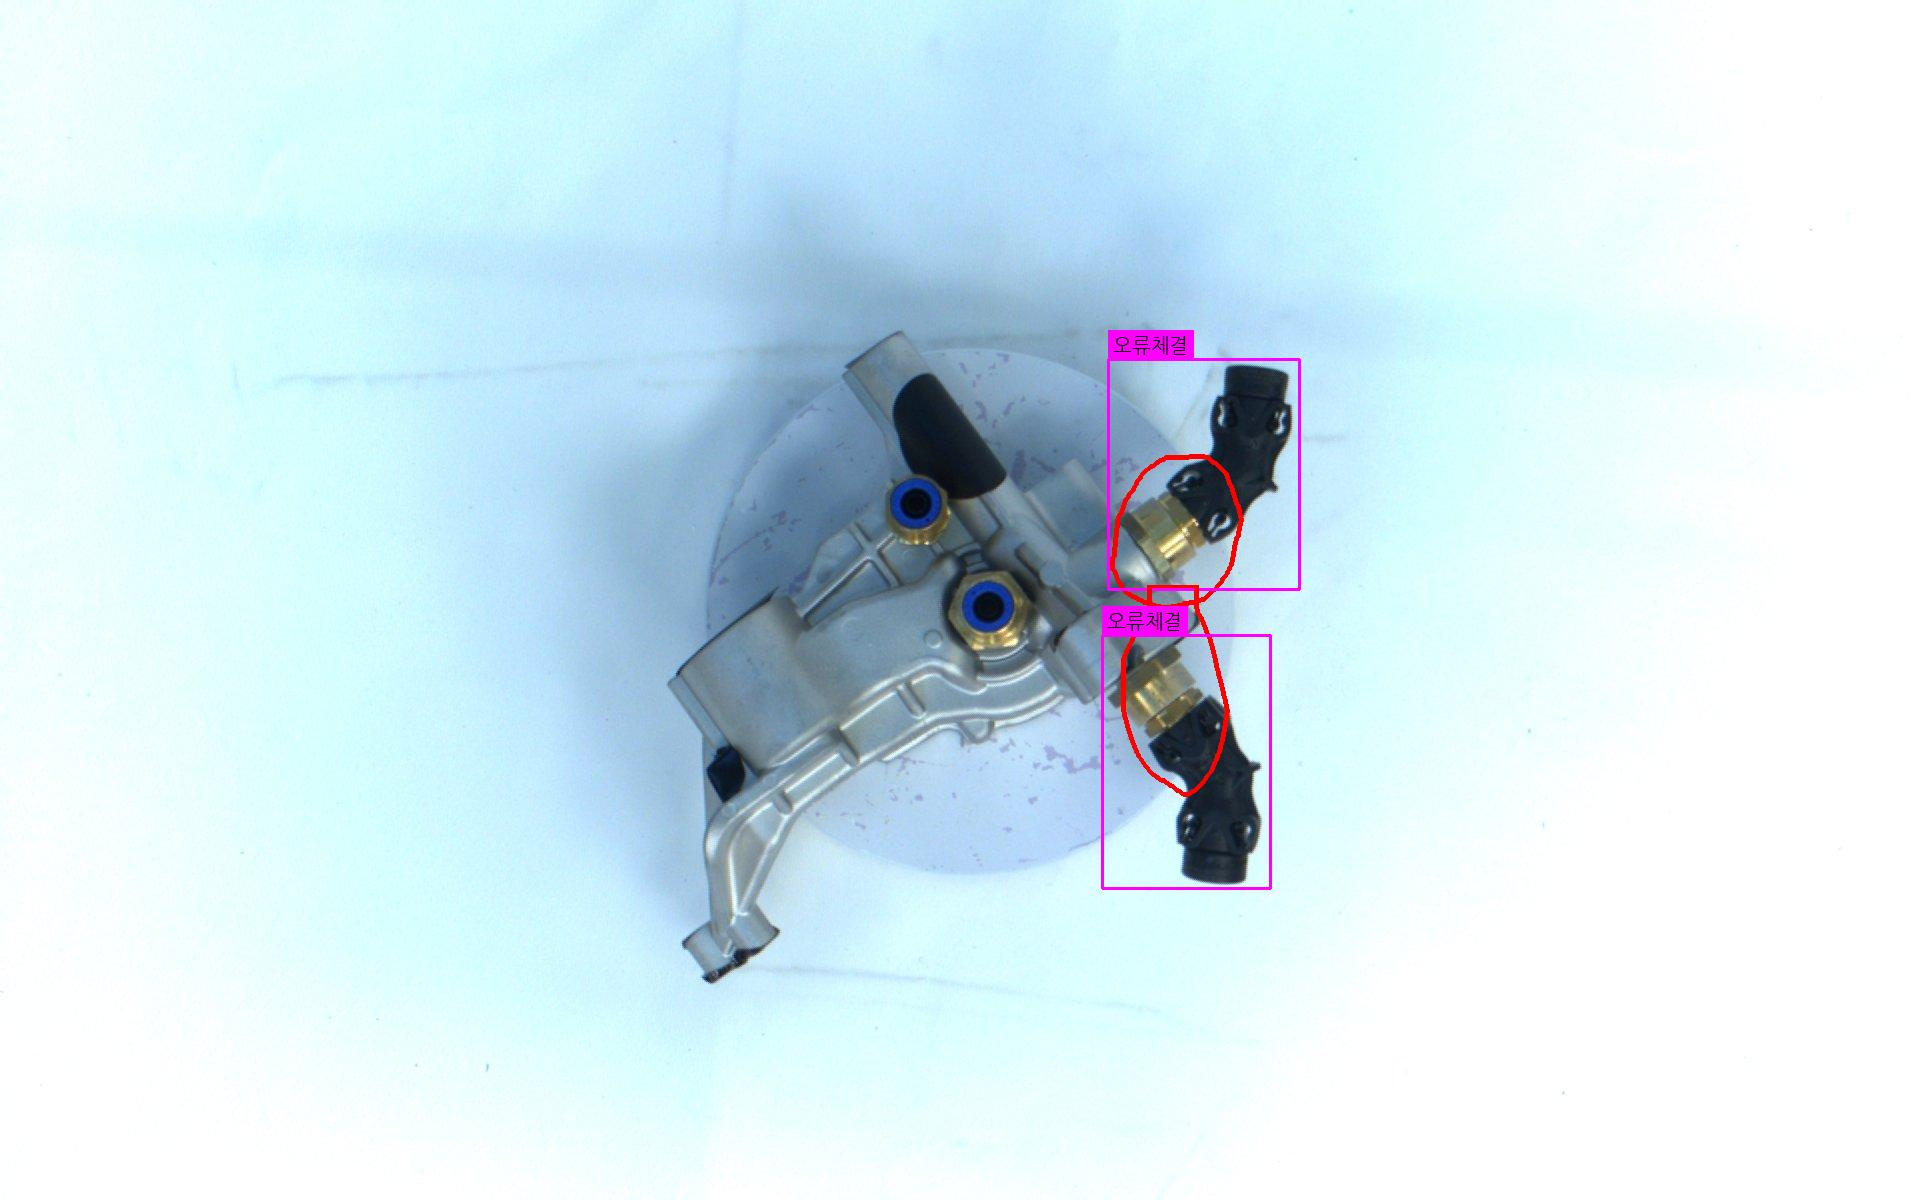

In [28]:
from IPython.display import clear_output
import random
import matplotlib.pyplot as plt
import glob

test_images = glob.glob('/content/llm_dataset/test/**/*.jpg', recursive=True)

if test_images:
    print("테스트 데이터셋에서 불량(이상)이 있는 이미지를 탐색합니다...")
    random.shuffle(test_images)
    anomaly_found = False

    for img_path in test_images[:50]:
        clear_output(wait=True)
        print(f"[비전 검사 진행 중] 이미지 경로: {img_path}")

        results, final_img = run_integrated_pipeline(img_path, eval_model, classification_model, target_layers)

        has_anomaly = False
        if results:
            has_anomaly = any(item['status'] != '정상' for item in results)

        if has_anomaly:
            print("\n🚨 불량 감지! AI 텍스트 생성 및 대시보드 렌더링 중...")

            # 대표 불량 상태 추출 (평가용 Query로 사용)
            anomalies = [item for item in results if item['status'] != '정상']
            representative_query = f"{anomalies[0]['part_name']} {anomalies[0]['status']}" if anomalies else ""

            # DB 로그 기록 및 RAG 컨텍스트 수집
            rag_contexts = []
            for item in results:
                if item['status'] != '정상':
                    log_incident(item['part_name'], item['status'])
                    actions = query_vector_db(item['part_name'], item['status'])
                    rag_contexts.append(f"{item['part_name']}: {actions}")

            combined_context = " ".join(rag_contexts)

            # Gemini 호출하여 텍스트 생성 (여기서만 API 1회 소진)
            ai_analysis_text = get_ai_root_cause_analysis(final_img, results)

            # 🚀 초경량 로컬 임베딩 평가 수행 (API 호출 없음)
            # emb_fn은 앞서 ChromaDB 세팅 시 정의한 임베딩 함수 변수입니다.
            dynamic_scores = get_lightweight_ragas_scores(
                query=representative_query,
                context=combined_context,
                answer=ai_analysis_text,
                emb_func=emb_fn
            )

            clear_output(wait=True)

            # HTML 템플릿에 AI 텍스트와 동적 계산된 RAGAS 점수를 주입하여 출력
            render_quality_report_with_ai(final_img, results, ai_analysis_text, ragas_scores=dynamic_scores)

            anomaly_found = True
            break
        else:
            plt.close('all')

    if not anomaly_found:
        clear_output(wait=True)
        print("탐색한 이미지 중에서 불량을 찾지 못했습니다.")
else:
    print("테스트 이미지가 없습니다. 경로를 확인해주세요.")